# Conditional GAN на MNIST

В этом ноутбуке мы реализуем и обучим условную генеративно-состязательную сеть (Conditional GAN) для генерации изображений цифр из датасета MNIST по заданному числу.

**Conditional GAN (cGAN)** расширяет обычный GAN, добавляя условие (label) в генератор и дискриминатор:
- **Generator (Генератор)** - создает изображение цифры на основе случайного шума и заданного числа (0-9)
- **Discriminator (Дискриминатор)** - проверяет, является ли изображение настоящим и соответствует ли оно заданному числу

Это позволяет контролировать, какую именно цифру генерировать.


## Импорты


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
import os

torch.manual_seed(42)
np.random.seed(42)
pl.seed_everything(42)


Seed set to 42


42

## Загрузка и визуализация датасета MNIST

Сначала загрузим датасет MNIST и посмотрим на примеры изображений с их метками.


In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root='../data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4
)

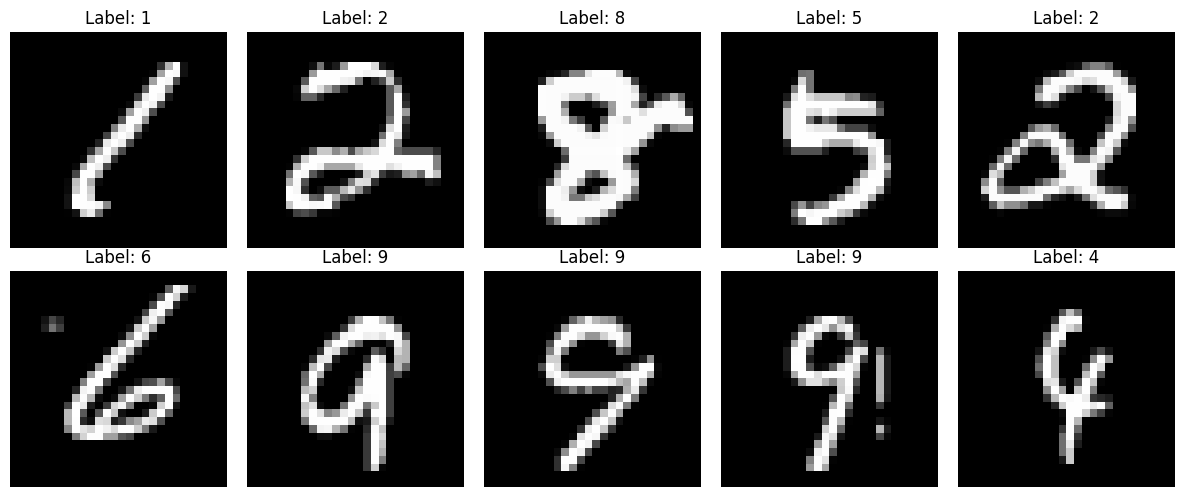

In [3]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    ax = axes[i // 5, i % 5]
    img = images[i].squeeze().numpy()
    img = (img + 1) / 2.0
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}')
    ax.axis('off')
plt.tight_layout()
plt.show()


## Классический подход к Conditional GAN

В оригинальной статье "Conditional Generative Adversarial Nets" (Mirza & Osindero, 2014) используется простой подход:

1. **Generator**: Принимает шум z и условие y (метку), объединяет их через конкатенацию: `concat(z, y)` → генерация изображения
2. **Discriminator**: Принимает изображение x и условие y, объединяет их через конкатенацию: `concat(x, y)` → классификация real/fake

**Ключевая идея**: Условие (метка) просто добавляется к входным данным через конкатенацию, без сложных проекций или embedding слоев.

## Архитектура Conditional Generator (классический подход)

Генератор принимает случайный вектор (шум) и метку класса (0-9). В классическом подходе метка представляется как one-hot вектор и конкатенируется с шумом.


In [4]:
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=100, num_classes=10):
        super().__init__()
        self.num_classes = num_classes

        # Вход: z (latent_dim) + one-hot метка (num_classes)
        self.model = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 28 * 28),
            nn.Tanh(),  # выход в диапазоне [-1, 1]
        )

    def forward(self, z, labels):
        # One-hot кодируем метки и конкатенируем с шумом
        labels_onehot = F.one_hot(labels, num_classes=self.num_classes).float()
        x = torch.cat([z, labels_onehot], dim=1)
        img = self.model(x)
        return img.view(img.size(0), 1, 28, 28)

## Архитектура Conditional Discriminator (классический подход)

Дискриминатор принимает изображение и метку класса. В классическом подходе изображение разворачивается в вектор, метка представляется как one-hot, и они конкатенируются перед подачей в сеть.


In [5]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.num_classes = num_classes

        # Вход: flatten(28x28) + one-hot метка (num_classes)
        self.model = nn.Sequential(
            nn.Linear(28 * 28 + num_classes, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),  # вероятность "настоящее изображение с правильной меткой"
        )

    def forward(self, img, labels):
        # Разворачиваем изображение и конкатенируем с one-hot меткой
        img_flat = img.view(img.size(0), -1)
        labels_onehot = F.one_hot(labels, num_classes=self.num_classes).float()
        x = torch.cat([img_flat, labels_onehot], dim=1)
        return self.model(x)

## PyTorch Lightning модуль для Conditional GAN

Создаем Lightning модуль, который объединяет генератор и дискриминатор, и реализует логику обучения Conditional GAN. На каждом шаге обучения передаем метки классов в обе сети.


In [6]:
class ConditionalGAN(pl.LightningModule):
    def __init__(self, latent_dim=100, lr=0.0002, b1=0.5, b2=0.999):
        super().__init__()
        self.save_hyperparameters()

        self.automatic_optimization = False

        self.generator = ConditionalGenerator(latent_dim)
        self.discriminator = ConditionalDiscriminator()

        self.latent_dim = latent_dim
        self.lr = lr
        self.b1 = b1
        self.b2 = b2

        self.validation_labels = torch.arange(10).repeat(6)
        self.validation_z = torch.randn(60, latent_dim)

    def forward(self, z, labels):
        return self.generator(z, labels)

    def adversarial_loss(self, y_hat, y):
        return F.binary_cross_entropy(y_hat, y)

    def training_step(self, batch, batch_idx):
        imgs, labels = batch
        batch_size = imgs.size(0)
        device = imgs.device

        opt_g, opt_d = self.optimizers()

        real_target = torch.ones(batch_size, 1, device=device)
        fake_target = torch.zeros(batch_size, 1, device=device)

        # ── Дискриминатор ──
        opt_d.zero_grad()

        # 1a. Настоящие + правильные метки → 1
        real_pred = self.discriminator(imgs, labels)
        loss_real = self.adversarial_loss(real_pred, real_target)

        # 1b. Поддельные + правильные метки → 0
        z = torch.randn(batch_size, self.latent_dim, device=device)
        fake_imgs = self.generator(z, labels).detach()
        fake_pred = self.discriminator(fake_imgs, labels)
        loss_fake = self.adversarial_loss(fake_pred, fake_target)

        # 1c. Настоящие + неправильные метки → 0
        wrong_labels = (labels + torch.randint(1, 10, (batch_size,), device=device)) % 10
        wrong_pred = self.discriminator(imgs, wrong_labels)
        loss_wrong = self.adversarial_loss(wrong_pred, fake_target)

        d_loss = (loss_real + loss_fake + loss_wrong) / 3
        self.manual_backward(d_loss)
        opt_d.step()

        # ── Генератор ──
        opt_g.zero_grad()

        z = torch.randn(batch_size, self.latent_dim, device=device)
        fake_imgs = self.generator(z, labels)
        gen_pred = self.discriminator(fake_imgs, labels)
        g_loss = self.adversarial_loss(gen_pred, real_target)

        self.manual_backward(g_loss)
        opt_g.step()

        self.log('g_loss', g_loss, prog_bar=True)
        self.log('d_loss', d_loss, prog_bar=True)

    def configure_optimizers(self):
        opt_g = torch.optim.Adam(
            self.generator.parameters(),
            lr=self.lr,
            betas=(self.b1, self.b2)
        )
        opt_d = torch.optim.Adam(
            self.discriminator.parameters(),
            lr=self.lr,
            betas=(self.b1, self.b2)
        )
        return [opt_g, opt_d], []

    def on_train_epoch_end(self):
        save_dir = 'generated_images'
        os.makedirs(save_dir, exist_ok=True)

        z = self.validation_z.type_as(next(self.generator.parameters()))
        labels = self.validation_labels.type_as(z).long()
        sample_imgs = self.generator(z, labels)

        fig, axes = plt.subplots(6, 10, figsize=(15, 9))
        for i in range(60):
            ax = axes[i // 10, i % 10]
            img = sample_imgs[i].squeeze().detach().cpu().numpy()
            img = (img + 1) / 2.0
            ax.imshow(img, cmap='gray')
            ax.set_title(f'{labels[i].item()}', fontsize=8)
            ax.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f'conditional_gan_epoch_{self.current_epoch:03d}.png'))
        plt.close()

        # add_image доступен только у TensorBoardLogger
        from pytorch_lightning.loggers import TensorBoardLogger
        if self.logger and isinstance(self.logger, TensorBoardLogger):
            grid = utils.make_grid(sample_imgs.detach(), nrow=10, normalize=True)
            self.logger.experiment.add_image('generated_images', grid, self.current_epoch)

In [7]:
model = ConditionalGAN(latent_dim=100, lr=0.0002)

checkpoint_callback = ModelCheckpoint(
    monitor='g_loss',
    mode='min',
    save_top_k=1,
    filename='conditional-gan-mnist-{epoch:02d}-{g_loss:.4f}'
)

trainer = pl.Trainer(
    max_epochs=50,
    accelerator='auto',
    devices=1,
    callbacks=[checkpoint_callback],
    enable_progress_bar=True
)

trainer.fit(model, train_loader)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ generator     │ ConditionalGenerator     │  1.5 M │ train │     0 │
│ 1 │ discriminator │ ConditionalDiscriminator │  1.5 M │ train │     0 │
└───┴───────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 3.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.0 M                                                                                                
Total estimated model params size (MB): 11                                                                         
Modules in train mode: 23                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


Output()

`Trainer.fit` stopped: `max_epochs=50` reached.


## Визуализация результатов

Генерируем изображения для каждой цифры от 0 до 9, чтобы показать, что модель научилась генерировать нужные цифры по заданному числу.


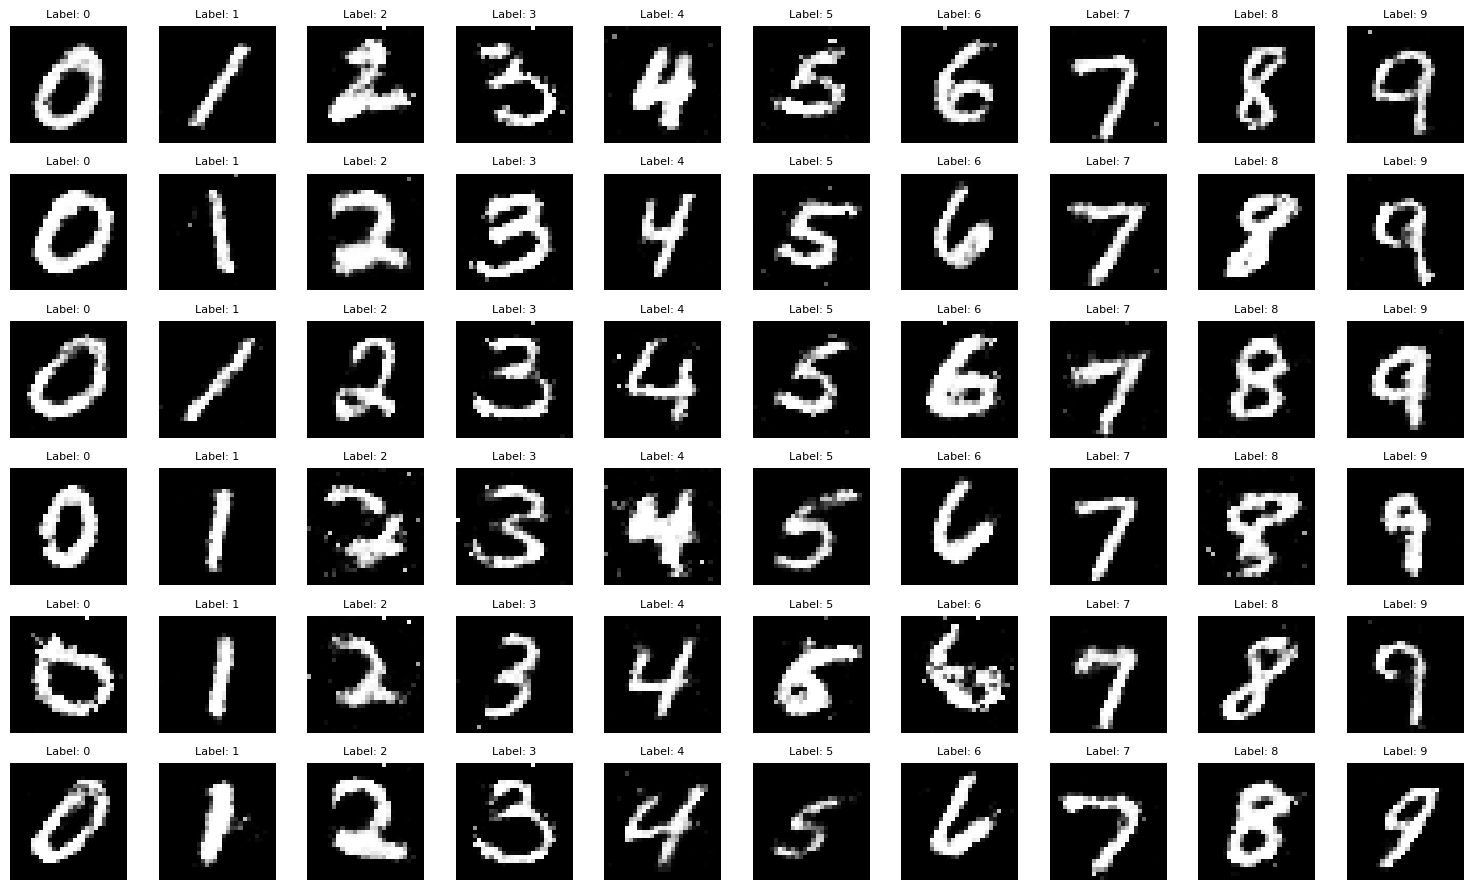

In [8]:
model.eval()
with torch.no_grad():
    labels_to_generate = torch.arange(10).repeat(6).type_as(next(model.generator.parameters())).long()
    z = torch.randn(60, 100)
    z = z.type_as(next(model.generator.parameters()))
    fake_imgs = model.generator(z, labels_to_generate)

fig, axes = plt.subplots(6, 10, figsize=(15, 9))
for i in range(60):
    ax = axes[i // 10, i % 10]
    img = fake_imgs[i].squeeze().cpu().numpy()
    img = (img + 1) / 2.0
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {labels_to_generate[i].item()}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()


## Генерация конкретных цифр

Теперь можно генерировать конкретные цифры, передавая нужное число в генератор.


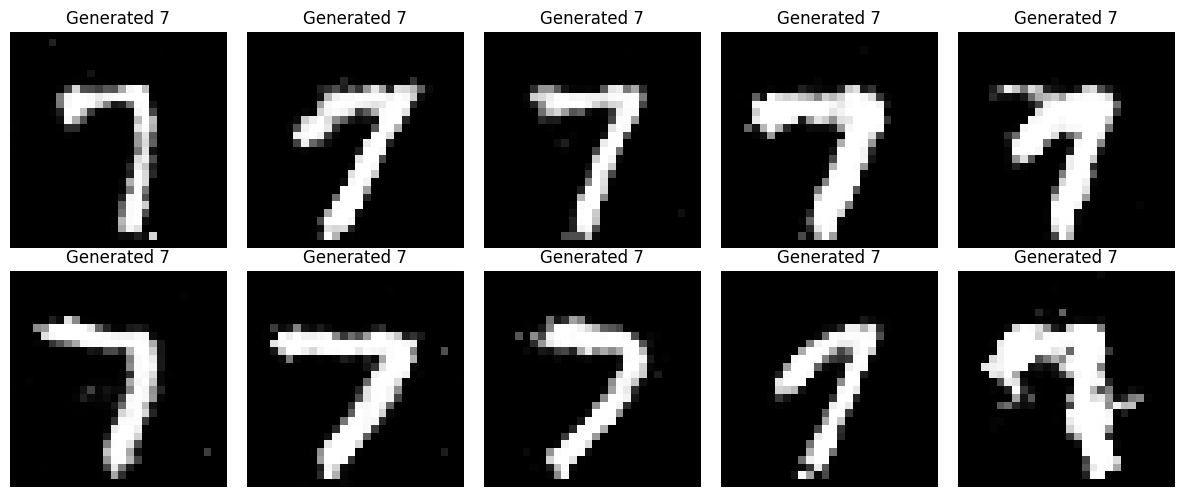

In [16]:
target_digit = 7
num_samples = 10

model.eval()
with torch.no_grad():
    z = torch.randn(num_samples, 100)
    z = z.type_as(next(model.generator.parameters()))
    labels = torch.full((num_samples,), target_digit).type_as(z).long()
    generated = model.generator(z, labels)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(num_samples):
    ax = axes[i // 5, i % 5]
    img = generated[i].squeeze().cpu().numpy()
    img = (img + 1) / 2.0
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Generated {target_digit}')
    ax.axis('off')
plt.tight_layout()
plt.show()
